# 🛍️ Mall Customer Segmentation using K-Means Clustering

## 🔹 1️⃣ Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 🔹 2️⃣ Load Dataset

In [4]:
df = pd.read_csv("E:\MALL CUSTOMER SEGMENTATION\Mall_Customers.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\REX\AppData\Local\Temp\ipykernel_24064\2585022057.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("E:\MALL CUSTOMER SEGMENTATION\Mall_Customers.csv")


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 🔹 3️⃣ Data Cleaning

In [ ]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

> ✅ No missing values in this dataset usually.

## 🔹 4️⃣ Exploratory Data Analysis

### Distribution of Age

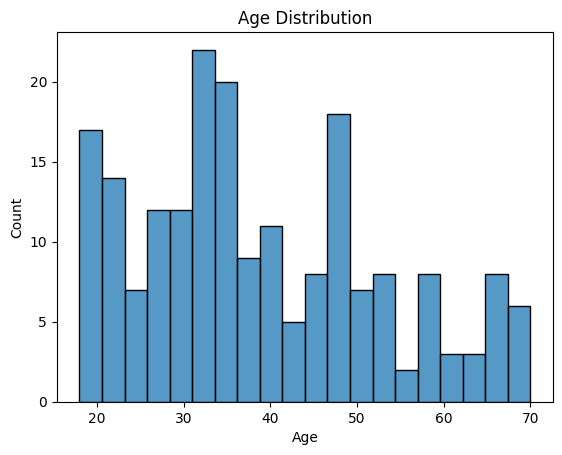

In [ ]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

### Income vs Spending Score

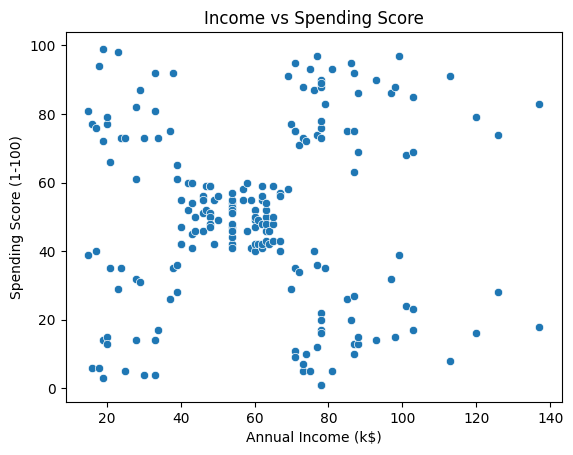

In [ ]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

## 🔹 5️⃣ Feature Selection

We use:
- **Annual Income**
- **Spending Score**

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## 🔹 6️⃣ Feature Scaling

> ⚠️ **Why scaling?** K-Means is distance-based → features must be normalized.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🔹 7️⃣ Elbow Method

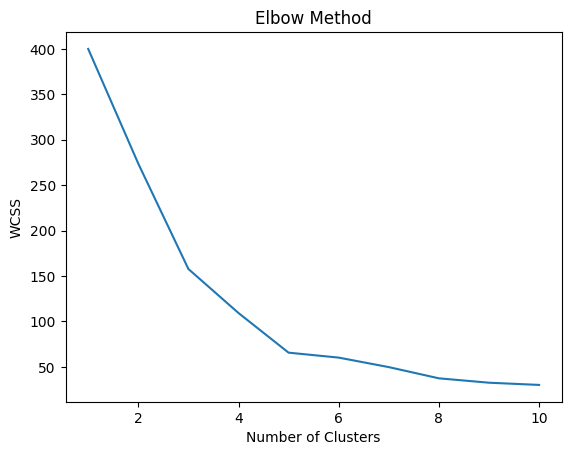

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

> 📌 **Optimal K = 5** based on the elbow curve.

## 🔹 8️⃣ Train Final Model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 🔹 9️⃣ Cluster Visualization

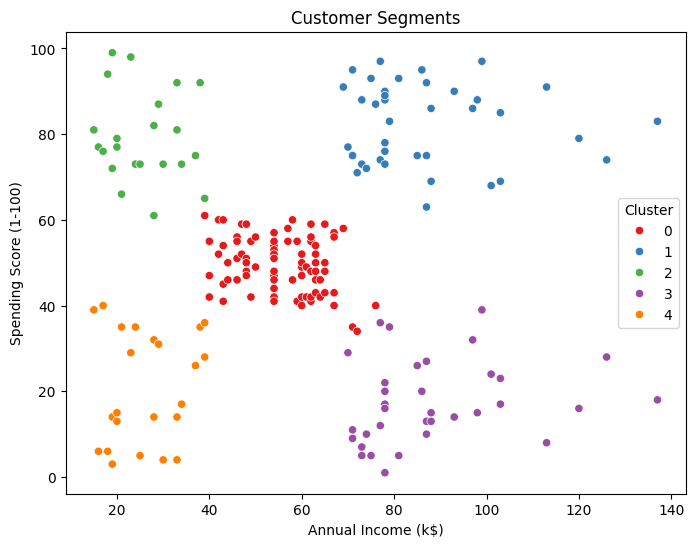

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()